In [13]:
import cartopy.crs as ccrs
import xarray as xr
import glob
import os
import matplotlib.pyplot as plt
import rioxarray as rxr
import numpy as np
import geopandas as gpd

In [14]:
# load data
nbhd_path = '/Users/josephko/USC/Research/Anthropogenic Heat/anthropogenic-heat-la/data/boundaries/la_bound_nbhd.geojson'
neighborhoods = gpd.read_file(nbhd_path)
# Remove Catalina Island (including Avalon) from dataframe
catalina_index = neighborhoods.query('name.str.contains("Catalina") | name.str.contains("Avalon")').index
neighborhoods.drop(catalina_index, inplace=True)
# make neighborhoods name all lower-case to match energy atlas name column
neighborhoods['name'] = neighborhoods['name'].str.lower()
neighborhoods.head()
deltas_dir = '/Users/josephko/USC/Research/Anthropogenic Heat/wrfout/wrf_output_deltas'
nc_files = glob.glob(f"{deltas_dir}/*.nc")
deltas = {}
for f in nc_files:
    filename = os.path.basename(f)
    delta_id = filename.split('.')[0]
    ds = xr.open_dataset(f)
    deltas[delta_id] = ds

In [15]:
# define wrf crs
ds = deltas['ah_off-ah_default-08'] # sample delta ds
wrf_crs = ds['spatial_ref'].crs_wkt
print(wrf_crs)

PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370000,0]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",37.1646919250488],PARAMETER["central_meridian",-120.5],PARAMETER["standard_parallel_1",30],PARAMETER["standard_parallel_2",60],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


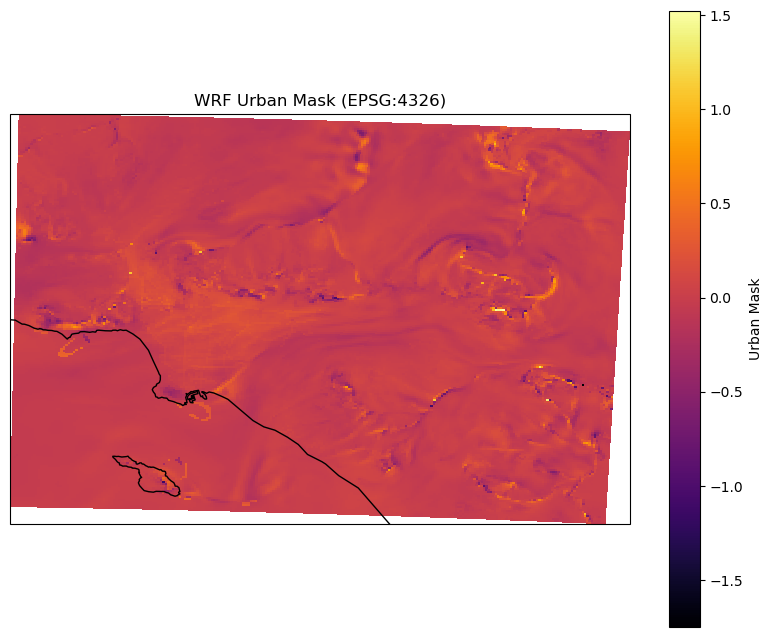

In [16]:
# EPSG:4326 is PlateCarree in Cartopy
crs = ccrs.PlateCarree()

da = ds['T2'].isel(Time=1).values
lat = ds['XLAT'].values
lon = ds['XLONG'].values

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': crs})
pcm = ax.pcolormesh(lon, lat, da, cmap='inferno', shading='auto', transform=crs)
ax.coastlines()
ax.set_title("WRF Urban Mask (EPSG:4326)")
plt.colorbar(pcm, ax=ax, label='Urban Mask')
plt.show()

In [17]:
deltas['ah_off-ah_default-08'].keys()

KeysView(<xarray.Dataset> Size: 189MB
Dimensions:      (y: 192, x: 244, Time: 168)
Coordinates:
    XLAT         (y, x) float32 187kB 33.25 33.25 33.25 ... 34.92 34.92 34.92
    XLONG        (y, x) float32 187kB -119.1 -119.0 -119.0 ... -116.3 -116.3
  * Time         (Time) datetime64[ns] 1kB 2016-08-12 ... 2016-08-18T23:00:00
  * y            (y) float64 2kB -4.254e+05 -4.244e+05 ... -2.354e+05 -2.344e+05
  * x            (x) float64 2kB 1.325e+05 1.335e+05 ... 3.745e+05 3.755e+05
    hour         (Time) int64 1kB ...
Data variables:
    T2           (Time, y, x) float32 31MB ...
    TC_URB       (Time, y, x) float32 31MB ...
    WS           (Time, y, x) float32 31MB ...
    PBLH         (Time, y, x) float32 31MB ...
    FRC_URB2D    (Time, y, x) float32 31MB ...
    AHFLUX       (Time, y, x) float32 31MB ...
    spatial_ref  int64 8B ...)

# 2m Air Temp

In [26]:
# turn temp into raster and reproject to match neighborhood gdf
v = 'AHFLUX'
m = 8
target = 'ah_default'
control = 'ah_off'
delta_id = f'{control}-{target}-{m:02d}'
# da = deltas[delta_id][v]
mean_ahf = deltas[delta_id][v].mean(dim='Time')
mean_ahf = mean_ahf.drop_vars(["XLAT", "XLONG"], errors="ignore")
mean_ahf.rio.write_crs(wrf_crs, inplace=True)
# reproject to match neighborhood gdf
mean_ahf = mean_ahf.rio.reproject('EPSG:4326')
print(mean_ahf.rio.crs)
print(mean_ahf.coords)

EPSG:4326
Coordinates:
  * x            (x) float64 2kB -119.1 -119.0 -119.0 ... -116.3 -116.3 -116.3
  * y            (y) float64 1kB 35.0 34.99 34.98 34.97 ... 33.2 33.19 33.18
    spatial_ref  int64 8B 0


In [31]:
# turn ahf into raster and reproject to match neighborhood gdf
v = 'T2'
m = 8
target = 'ah_default'
control = 'ah_off'
delta_id = f'{control}-{target}-{m:02d}'
# da = deltas[delta_id][v]
mean_delta_t2 = deltas[delta_id][v].mean(dim='Time')
mean_delta_t2 = mean_delta_t2.drop_vars(["XLAT", "XLONG"], errors="ignore")
mean_delta_t2.rio.write_crs(wrf_crs, inplace=True)
# reproject to match neighborhood gdf
mean_delta_t2 = mean_delta_t2.rio.reproject('EPSG:4326')
print(mean_delta_t2.rio.crs)
print(mean_delta_t2.coords)
# Mask unrealistic values
da_memean_delta_t2 = mean_delta_t2.where(mean_delta_t2 < 100)
# Explicitly set nodata in the raster metadata
mean_delta_t2.rio.write_nodata(np.nan, inplace=True)

EPSG:4326
Coordinates:
  * x            (x) float64 2kB -119.1 -119.0 -119.0 ... -116.3 -116.3 -116.3
  * y            (y) float64 1kB 35.0 34.99 34.98 34.97 ... 33.2 33.19 33.18
    spatial_ref  int64 8B 0


<xarray.DataArray 'T2' (y: 178, x: 269)> Size: 192kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(178, 269), dtype=float32)
Coordinates:
  * x            (x) float64 2kB -119.1 -119.0 -119.0 ... -116.3 -116.3 -116.3
  * y            (y) float64 1kB 35.0 34.99 34.98 34.97 ... 33.2 33.19 33.18
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [29]:
neighborhoods.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

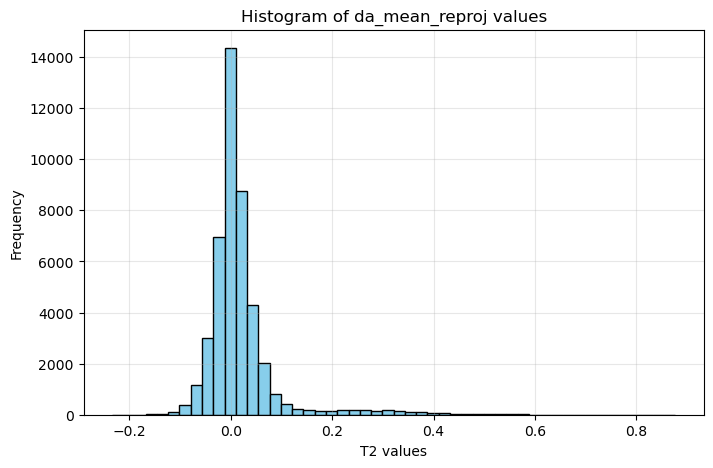

In [32]:
# Flatten the raster to 1D, ignoring NaNs
values = mean_delta_t2.values.flatten()
values = values[~np.isnan(values)]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(values, bins=50, color='skyblue', edgecolor='k')
plt.xlabel(f"{mean_delta_t2.name} values")
plt.ylabel("Frequency")
plt.title("Histogram of da_mean_reproj values")
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
means = []
means_ahf = []

for i, row in neighborhoods.iterrows():
    geom = [row.geometry]
    
    try:
        clipped = mean_delta_t2.rio.clip(geom, neighborhoods.crs, drop=True, invert=False)
        mean_val = float(clipped.mean().values)
    except Exception as e:
        mean_val = np.nan
    means.append(mean_val)
    
    try:
        clipped_ahf = mean_ahf.rio.clip(geom, neighborhoods.crs, drop=True, invert=False)
        mean_val_ahf = float(clipped_ahf.mean().values)
    except Exception as e:
        mean_val_ahf = np.nan
    means_ahf.append(mean_val_ahf)

neighborhoods["mean_delta_t2"] = means
neighborhoods["mean_ahf"] = means_ahf

In [34]:
neighborhoods.head()

,external_i,name,location,latitude,slug_1,sqmi,display_na,set,slug,longitude,name_1,kind,type,geometry,mean_delta_t2,mean_ahf
0,acton,acton,POINT(34.497355239240846 -118.16981019229348),-118.16981019229348,None,39.3391089485,Acton L.A. County Neighborhood (Current),L.A. County Neighborhoods (Current),acton,34.497355239240846,None,L.A. County Neighborhood (Current),unincorporated-area,"MULTIPOLYGON (((-118.20262 34.53899, -118.1894...",-0.019821,30.423594
1,adams-normandie,adams-normandie,POINT(34.031461499124156 -118.30020800000011),-118.30020800000011,None,0.805350187789,Adams-Normandie L.A. County Neighborhood (Curr...,L.A. County Neighborhoods (Current),adams-normandie,34.031461499124156,None,L.A. County Neighborhood (Current),segment-of-a-city,"MULTIPOLYGON (((-118.30901 34.03741, -118.3004...",0.361572,23.704987
2,agoura-hills,agoura hills,POINT(34.146736499122795 -118.75988450000015),-118.75988450000015,None,8.14676029818,Agoura Hills L.A. County Neighborhood (Current),L.A. County Neighborhoods (Current),agoura-hills,34.146736499122795,None,L.A. County Neighborhood (Current),standalone-city,"MULTIPOLYGON (((-118.76193 34.1682, -118.72632...",0.047971,17.155861
3,agua-dulce,agua dulce,POINT(34.504926999796837 -118.3171036690717),-118.3171036690717,None,31.4626319451,Agua Dulce L.A. County Neighborhood (Current),L.A. County Neighborhoods (Current),agua-dulce,34.504926999796837,None,L.A. County Neighborhood (Current),unincorporated-area,"MULTIPOLYGON (((-118.25468 34.5583, -118.25551...",-0.017806,17.473768
4,alhambra,alhambra,POINT(34.085538999123571 -118.13651200000021),-118.13651200000021,None,7.62381430605,Alhambra L.A. County Neighborhood (Current),L.A. County Neighborhoods (Current),alhambra,34.085538999123571,None,L.A. County Neighborhood (Current),standalone-city,"MULTIPOLYGON (((-118.12175 34.10504, -118.1168...",0.366055,12.599656


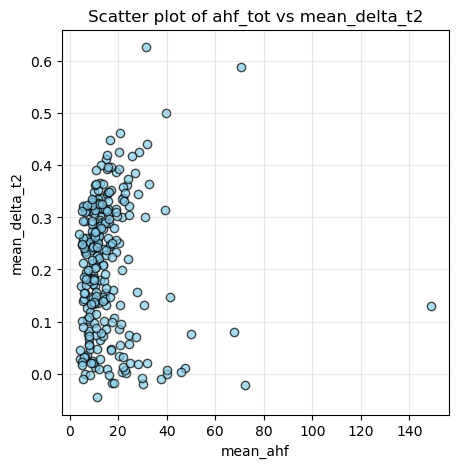

In [37]:
# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(
    neighborhoods['mean_ahf'],
    neighborhoods['mean_delta_t2'],
    color='skyblue', edgecolor='k', alpha=0.7
)

plt.xlabel("mean_ahf")
plt.ylabel("mean_delta_t2")
plt.title("Scatter plot of ahf_tot vs mean_delta_t2")
plt.grid(alpha=0.3)
plt.show()

In [47]:
from libpysal.weights import Queen
gdf = neighborhoods.copy()
# Drop NaNs FIRST
gdf = gdf.dropna(subset=['mean_delta_t2', 'mean_ahf'])
w = Queen.from_dataframe(gdf)
w.transform = 'r'   # row-standardize

('WARNING: ', 5, ' is an island (no neighbors)')
('WARNING: ', 44, ' is an island (no neighbors)')
('WARNING: ', 48, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
('WARNING: ', 59, ' is an island (no neighbors)')
('WARNING: ', 61, ' is an island (no neighbors)')
('WARNING: ', 67, ' is an island (no neighbors)')
('WARNING: ', 69, ' is an island (no neighbors)')
('WARNING: ', 71, ' is an island (no neighbors)')
('WARNING: ', 83, ' is an island (no neighbors)')
('WARNING: ', 113, ' is an island (no neighbors)')
('WARNING: ', 124, ' is an island (no neighbors)')
('WARNING: ', 136, ' is an island (no neighbors)')
('WARNING: ', 145, ' is an island (no neighbors)')
('WARNING: ', 148, ' is an island (no neighbors)')
('WARNING: ', 149, ' is an island (no neighbors)')
('WARNING: ', 152, ' is an island (no neighbors)')
('WARNING: ', 161, ' is an island (no neighbors)')
('WARNING: ', 174, ' is an island (no neighbors)')
('WARNING: ', 179, ' is an island (no neig

/var/folders/4m/_rb2pz1d7jx9ywsn916lhr_c0000gn/T/ipykernel_71871/671594294.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/Users/josephko/miniconda3/envs/wrf-analysis/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 48 disconnected components.
 There are 36 islands with ids: 5, 44, 48, 49, 59, 61, 67, 69, 71, 83, 113, 124, 136, 145, 148, 149, 152, 161, 174, 179, 185, 186, 198, 205, 218, 219, 221, 229, 234, 238, 241, 244, 246, 248, 257, 258.
  W.__init__(self, neighbors, ids=ids, **kw)


In [48]:
# cheeck for missing values / nans
print(gdf.isna().sum())

# print which neighborhoods have missing values for mean_delta_t2
print(gdf[gdf['mean_delta_t2'].isna()]['name'])

external_i         0
name               0
location           0
latitude           0
slug_1           267
sqmi               0
display_na         0
set                0
slug               0
longitude          0
name_1           267
kind               0
type               0
geometry           0
mean_delta_t2      0
mean_ahf           0
dtype: int64
Series([], Name: name, dtype: object)


In [49]:
# fit baseline OLS
from spreg import OLS

y = gdf["mean_delta_t2"].values.reshape(-1,1)
X = gdf[["mean_ahf"]].values

ols = OLS(y, X)

In [50]:
# get OLS residuals
residuals = ols.u
len(residuals)

267

In [51]:
from esda.moran import Moran

moran = Moran(residuals, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.723143079813197
p-value: 0.001


In [52]:
from spreg import ML_Lag
y = gdf["mean_delta_t2"].values.reshape(-1, 1)
X = gdf[["mean_ahf"]].values
slm = ML_Lag(
    y,
    X,
    w=w,
    name_y='mean_delta_t2',
    name_x=['mean_ahf']
)

print(slm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :mean_delta_t2                Number of Observations:         267
Mean dependent var  :      0.2090                Number of Variables   :           3
S.D. dependent var  :      0.1281                Degrees of Freedom    :         264
Pseudo R-squared    :      0.3767
Spatial Pseudo R-squared:  0.0039
Log likelihood      :    219.4494
Sigma-square ML     :      0.0104                Akaike info criterion :    -432.899
S.E of regression   :      0.1021                Schwarz criterion     :    -422.137

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------

In [53]:
print(gdf[['mean_ahf', 'mean_delta_t2']].describe())
print(gdf[['mean_ahf', 'mean_delta_t2']].corr())

         mean_ahf  mean_delta_t2
count  267.000000     267.000000
mean    15.562051       0.208994
std     13.018963       0.128121
min      3.935568      -0.044284
25%      9.131169       0.102111
50%     12.240824       0.227020
75%     17.718706       0.311555
max    149.064224       0.625831
               mean_ahf  mean_delta_t2
mean_ahf       1.000000      -0.017993
mean_delta_t2 -0.017993       1.000000


# Canopy Air Temp